# 05 — Análise de robustez e poder estatístico (post-hoc)

Este notebook responde: **dado N=32 e os splits dos subgrupos, qual é o efeito mínimo
detectável (MDE) com α=0.05 e poder=80%?**

Tradicional G*Power assume distribuições normais; aqui simulamos sob o teste que de
fato usamos (Mann–Whitney U) e em escala Likert 1-5 — mais transparente.

**Metodologia (Monte Carlo):**
1. Para cada candidato δ ∈ \[0.05, 0.85\], converte para shift na escala latente
   normal via δ = 2·Φ(d/√2) − 1.
2. Gera N1 valores latentes ~ N(d, 1), N2 valores ~ N(0, 1).
3. Discretiza para Likert 5 níveis via cortes nos quantis padrão (-1.28, -0.52, 0.52, 1.28).
4. Roda MWU two-sided; registra p < 0.05.
5. Repete `n_reps` vezes; poder = fração de rejeições.
6. MDE = menor δ com poder ≥ 0.8.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
RNG = np.random.default_rng(42)

print(f"sklearn / scikit-posthocs / pingouin disponíveis via U.* helpers")


sklearn / scikit-posthocs / pingouin disponíveis via U.* helpers


## 1. Função de simulação de poder


In [2]:
# Cortes Likert: simétricos no normal padrão para 5 categorias com massas ~ (10, 25, 30, 25, 10)%
LIKERT_CUTS = np.array([-1.282, -0.524, 0.524, 1.282])

def discretize_likert(z: np.ndarray) -> np.ndarray:
    return np.searchsorted(LIKERT_CUTS, z) + 1  # 1..5

def delta_to_shift(delta: float) -> float:
    """δ = 2·Φ(d/√2) − 1  ⇒  d = √2 · Φ⁻¹((δ+1)/2)."""
    return float(np.sqrt(2) * stats.norm.ppf((delta + 1) / 2))

def simulate_power(n1: int, n2: int, delta: float, n_reps: int = 2000,
                   alpha: float = 0.05, rng=None) -> float:
    if rng is None:
        rng = np.random.default_rng()
    d = delta_to_shift(delta)
    rejections = 0
    for _ in range(n_reps):
        x = rng.normal(d, 1.0, size=n1)
        y = rng.normal(0.0, 1.0, size=n2)
        x_l = discretize_likert(x)
        y_l = discretize_likert(y)
        try:
            p = stats.mannwhitneyu(x_l, y_l, alternative="two-sided").pvalue
        except ValueError:
            p = 1.0
        if p < alpha:
            rejections += 1
    return rejections / n_reps

# Sanity check
p0 = simulate_power(20, 12, delta=0.0, n_reps=1000, rng=np.random.default_rng(7))
print(f"δ=0 (H0): poder ≈ {p0:.3f} (esperado ≈ 0.05)")


δ=0 (H0): poder ≈ 0.047 (esperado ≈ 0.05)


## 2. Curvas de poder por subgrupo


In [3]:
splits = [
    ("Sêniores × Juniores", 20, 12),
    ("Cient. dados × Devs", 18, 10),
    (">3 projetos × ≤3", 17, 15),
    ("Homens × Mulheres", 24, 8),
    ("Pareado N=32",       32, 32),  # ref Wilcoxon — mesmo n
]

deltas = np.round(np.arange(0.05, 0.86, 0.05), 2)
n_reps = 2000

power_rows = []
for label, n1, n2 in splits:
    for d in deltas:
        pw = simulate_power(n1, n2, d, n_reps=n_reps, rng=np.random.default_rng(42))
        power_rows.append({"split": label, "n1": n1, "n2": n2, "delta": d, "power": pw})

power_df = pd.DataFrame(power_rows)
print(power_df.head())


                 split  n1  n2  delta   power
0  Sêniores × Juniores  20  12   0.05  0.0465
1  Sêniores × Juniores  20  12   0.10  0.0640
2  Sêniores × Juniores  20  12   0.15  0.0985
3  Sêniores × Juniores  20  12   0.20  0.1460
4  Sêniores × Juniores  20  12   0.25  0.2050


In [4]:
# MDE por split (menor δ com poder ≥ 0.8)
mde_rows = []
for label in power_df["split"].unique():
    sub = power_df[power_df["split"] == label].sort_values("delta")
    above = sub[sub["power"] >= 0.80]
    if len(above):
        mde = float(above.iloc[0]["delta"])
        achieved = float(above.iloc[0]["power"])
    else:
        mde = float("nan")
        achieved = float(sub["power"].max())
    mde_rows.append({"split": label,
                     "n1": int(sub.iloc[0]["n1"]),
                     "n2": int(sub.iloc[0]["n2"]),
                     "MDE_delta_p80": mde,
                     "MDE_magnitude": U.classify_cliffs_delta(mde) if mde == mde else "—",
                     "max_power_observed": achieved})

mde_df = pd.DataFrame(mde_rows)
print("=== Efeito mínimo detectável (poder ≥ 0.8, α=0.05) ===")
print(mde_df.to_string(index=False))


=== Efeito mínimo detectável (poder ≥ 0.8, α=0.05) ===
              split  n1  n2  MDE_delta_p80 MDE_magnitude  max_power_observed
Sêniores × Juniores  20  12           0.60         large              0.8305
Cient. dados × Devs  18  10           0.65         large              0.8470
   >3 projetos × ≤3  17  15           0.60         large              0.8550
  Homens × Mulheres  24   8           0.65         large              0.8150
       Pareado N=32  32  32           0.45        medium              0.8750


## 3. Plot — curvas de poder por subgrupo


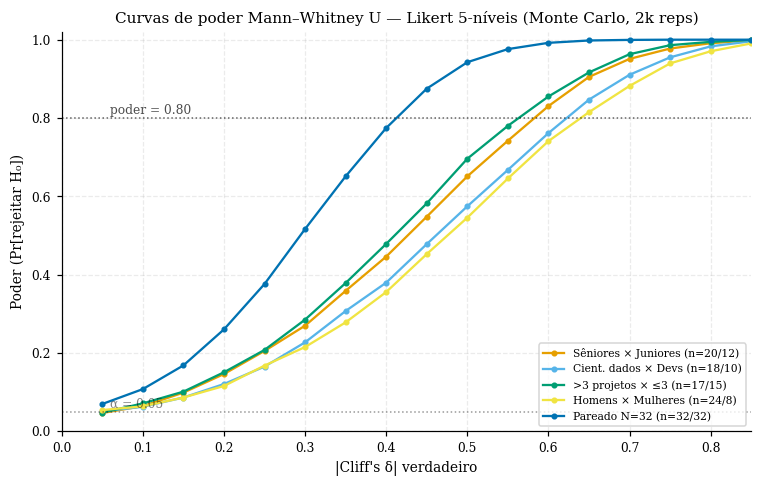

In [5]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))
for i, label in enumerate(power_df["split"].unique()):
    sub = power_df[power_df["split"] == label].sort_values("delta")
    color = U.PALETTE_WONG[(i + 1) % len(U.PALETTE_WONG)]
    ax.plot(sub["delta"], sub["power"], marker="o", markersize=3,
            color=color, linewidth=1.5, label=f"{label} (n={sub.iloc[0]['n1']}/{sub.iloc[0]['n2']})")

ax.axhline(0.80, color="black", linestyle=":", linewidth=1, alpha=0.6)
ax.text(0.06, 0.81, "poder = 0.80", fontsize=8, color="black", alpha=0.7)
ax.axhline(0.05, color="black", linestyle=":", linewidth=1, alpha=0.4)
ax.text(0.06, 0.06, "α = 0.05", fontsize=8, color="black", alpha=0.5)

ax.set_xlabel("|Cliff's δ| verdadeiro")
ax.set_ylabel("Poder (Pr[rejeitar H₀])")
ax.set_title("Curvas de poder Mann–Whitney U — Likert 5-níveis (Monte Carlo, 2k reps)")
ax.set_xlim(0, 0.85)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right", fontsize=7)
fig.tight_layout()
U.save_fig(fig, "power_curves")
plt.show()


## 4. Salva tabelas


In [6]:
power_df.to_csv(TABLES / "power_simulation.csv", index=False)
mde_df.to_csv(TABLES / "mde_per_split.csv", index=False)
print("-> tables/power_simulation.csv, tables/mde_per_split.csv")
print("-> figures/power_curves.pdf")


-> tables/power_simulation.csv, tables/mde_per_split.csv
-> figures/power_curves.pdf


## 5. Texto plug-and-play para Threats to Validity

Conclusão típica para o paper (auto-gera após executar):


In [7]:
lines = ["**Análise de sensibilidade post-hoc (Monte Carlo, MWU em Likert 5-níveis):**"]
for _, r in mde_df.iterrows():
    if r["MDE_delta_p80"] == r["MDE_delta_p80"]:
        lines.append(
            f"- *{r['split']}* (n={r['n1']}/{r['n2']}): "
            f"MDE = |δ| ≥ {r['MDE_delta_p80']:.2f} ({r['MDE_magnitude']}); "
            f"efeitos abaixo desse limiar têm poder < 80%."
        )
    else:
        lines.append(
            f"- *{r['split']}* (n={r['n1']}/{r['n2']}): mesmo |δ|=0.85 só atinge "
            f"poder = {r['max_power_observed']:.2f} — split é severamente subdimensionado."
        )
print("\n".join(lines))


**Análise de sensibilidade post-hoc (Monte Carlo, MWU em Likert 5-níveis):**
- *Sêniores × Juniores* (n=20/12): MDE = |δ| ≥ 0.60 (large); efeitos abaixo desse limiar têm poder < 80%.
- *Cient. dados × Devs* (n=18/10): MDE = |δ| ≥ 0.65 (large); efeitos abaixo desse limiar têm poder < 80%.
- *>3 projetos × ≤3* (n=17/15): MDE = |δ| ≥ 0.60 (large); efeitos abaixo desse limiar têm poder < 80%.
- *Homens × Mulheres* (n=24/8): MDE = |δ| ≥ 0.65 (large); efeitos abaixo desse limiar têm poder < 80%.
- *Pareado N=32* (n=32/32): MDE = |δ| ≥ 0.45 (medium); efeitos abaixo desse limiar têm poder < 80%.
